# Анализ ассортимента интернет-магазина методом ABC/XYZ

#### Автор: Анна Струкова
#### Дата: 06.10.2026

**Оглавление**

- [Этап 1. Знакомство с данными и очистка](#stage-1)
  - [Этап 1.1. Загрузка данных](#stage-1-1)
  - [Этап 1.2. Знакомство с данными](#stage-1-2)
  - [Этап 1.3. Проверка качества данных](#stage-1-3)
- [Этап 2. Базовая картина бизнеса](#stage-2)
  - [Этап 2.1. Основные бизнес-метрики](#stage-2-1)
  - [Этап 2.2. Кривая Парето](#stage-2-2)
- [Этап 3. ABC-анализ](#stage-3)
- [Этап 4. XYZ-анализ](#stage-4)
  - [Этап 4.1. Базовый XYZ-анализ](#stage-4-1)
  - [Этап 4.2. ABC-XYZ-анализ](#stage-4-2)
  - [Этап 4.3. Учёт сезонности](#stage-4-3)
- [Этап 5. Итоговый список SKU под сокращение и выводы](#stage-5)

<a id="stage-1"></a>
## Этап 1. Знакомство с данными и очистка

Загрузка библиотек

In [1]:
# Загружаем библиотеки для анализа и визуализации данных
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scp
import numpy as np

<a id="stage-1-1"></a>
### Этап 1.1. Загрузка данных

**ПРИМЕЧАНИЕ**

Для проверки блокнота загрузите файл `online_retail_II.xlsx` из текущего репозитория в папку на воем ПК и укажите к ней путь в ячейке ниже.

In [2]:
# Выносим путь к файлу в переменную
BASE_PATH = r'D:\Anna S\datasets\\'

In [3]:
# Выгружаем данные в датафрейм. 
# Данные у нас изначально на двух листах в файле .xlsx. Объединим и преобразуем в .csv сразу тут
FILE = BASE_PATH + 'online_retail_II.xlsx'

sheets = pd.read_excel(FILE, sheet_name=None, engine='openpyxl')
shop = pd.concat(sheets.values(), ignore_index=True)

shop.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


<a id="stage-1-2"></a>
### Этап 1.2. Знакомство с данными

In [4]:
# Общая информация о датасете
shop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


`Customer ID` надо преобразовать в Int64, остальное по типам данных корректно. У `Price` можно понизить разрядность.
Не приводим `Invoice` и `StockCode` к числам: это идентификаторы, в них могут быть и буквы.

In [5]:
# Customer ID — есть пропуски, поэтому nullable Int64, а не int64
shop['Customer ID'] = shop['Customer ID'].astype('Int64')

# Price — float64 → float32 (экономия памяти)
shop['Price'] = shop['Price'].astype('float32')

In [6]:
# Проверим. что типы обновились
shop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float32       
 6   Customer ID  824364 non-null   Int64         
 7   Country      1067371 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float32(1), int64(1), object(4)
memory usage: 62.1+ MB


<a id="stage-1-3"></a>
### Этап 1.3. Проверка качества данных

#### Быстрая проверка качества данных

In [7]:
print("Размер данных:", shop.shape)

print("\nПропуски:")
display(shop.isna().sum().to_frame("missing"))

print("\nОтрицательный Quantity:")
display(
    shop.loc[
        shop["Quantity"] < 0,
        [
            "Invoice",
            "StockCode",
            "Quantity",
            "Price",
        ],
    ].head()
)

print("\nОтрицательный Price:")
display(
    shop.loc[
        shop["Price"] < 0,
        [
            "Invoice",
            "StockCode",
            "Quantity",
            "Price",
        ],
    ].head()
)

print("\nДиапазон дат:")
print(
    shop["InvoiceDate"].min(),
    "—",
    shop["InvoiceDate"].max(),
)

Размер данных: (1067371, 8)

Пропуски:


,missing
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0



Отрицательный Quantity:


,Invoice,StockCode,Quantity,Price
178,C489449,22087,-12,2.95
179,C489449,85206A,-6,1.65
180,C489449,21895,-4,4.25
181,C489449,21896,-6,2.10
182,C489449,22083,-12,2.95



Отрицательный Price:


,Invoice,StockCode,Quantity,Price
179403,A506401,B,1,-53594.359375
276274,A516228,B,1,-44031.789062
403472,A528059,B,1,-38925.871094
825444,A563186,B,1,-11062.059570
825445,A563187,B,1,-11062.059570



Диапазон дат:
2009-12-01 07:45:00 — 2011-12-09 12:50:00


#### Промежуточные выводы:

Пропуски в `Description` - не критично. Мы не можем идентифицировать товар однозначно по названию, но у нас есть идентификатор товара `StockCode`. 

Пропуски в `Customer ID`	- допустимо. Возможно, это покупки за наличный расчет и/или без использования клиентской карты для идентификации клиента. Строки эти оставляем, дополнительно в них работать с этим типом пропусков не будем.

Отрицательные `Quantity` - вероятнее всего, это возвраты. Об этом же говорит и буква С в столбце `Invoice` (C - "Cancelled"). Для учебной демонстрации отфильтруем отрицатальные значения. Для более детального анализа хорошо бы учесть их + складские остатки.
Аналогично для отрицательных значений в `Price`.

#### Подробная проверка качества данных

Пропуски и дубли:

In [8]:
# Пропуски
for col in ['Invoice', 'StockCode', 'Description', 'Country']:
    bad = shop[col].astype('string').str.strip().str.upper().isin(['N/A', 'NA', 'NAN', '?', 'NONE'])
    print(col, bad.sum())

Invoice 0
StockCode 0
Description 92
Country 0


In [9]:
# Проверяем полные дубликаты в датафрейме food_df
shop.duplicated().sum()

34335

In [10]:
# Детально рассмотрим как выглядят дубли
dups = shop[shop.duplicated(keep=False)]
print(dups.sort_values(['Invoice', 'StockCode']).head(6))

# сколько уникальных Invoice среди дублей
print(dups['Invoice'].nunique())
print(dups['Invoice'].value_counts().head(6))

    Invoice StockCode                       Description  Quantity  \
379  489517     21491   SET OF THREE VINTAGE GIFT WRAPS         1   
391  489517     21491   SET OF THREE VINTAGE GIFT WRAPS         1   
365  489517     21821  GLITTER STAR GARLAND WITH BELLS          1   
386  489517     21821  GLITTER STAR GARLAND WITH BELLS          1   
363  489517     21912          VINTAGE SNAKES & LADDERS         1   
371  489517     21912          VINTAGE SNAKES & LADDERS         1   

            InvoiceDate  Price  Customer ID         Country  
379 2009-12-01 11:34:00   1.95        16329  United Kingdom  
391 2009-12-01 11:34:00   1.95        16329  United Kingdom  
365 2009-12-01 11:34:00   3.75        16329  United Kingdom  
386 2009-12-01 11:34:00   3.75        16329  United Kingdom  
363 2009-12-01 11:34:00   3.75        16329  United Kingdom  
371 2009-12-01 11:34:00   3.75        16329  United Kingdom  
5391
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186
53

In [11]:
#Удаляем полные дубли
shop = shop.drop_duplicates().reset_index(drop=True)
print('После удаления дублей:', shop.shape)

После удаления дублей: (1033036, 8)


Рассмотрим возвраты:

In [12]:
shop['is_return'] = shop['Quantity'] < 0

sales = shop[shop['Quantity'] > 0].copy()          # продажи
returns = shop[shop['Quantity'] < 0].copy()        # возвраты

print('Продажи, всего:', len(sales))
print('Возвраты:', len(returns))

Продажи, всего: 1010540
Возвраты: 22496


Отфильтруем отрицательные `Quantity`, `Price` и строки `Invoice`, содержащие в коде "C" (считаем их возвратами).

In [13]:
# Фильтрация
sales: pd.DataFrame = shop[
    (shop['Quantity'] > 0)
    & (~shop['Invoice'].astype('string').str.startswith('C'))
    & (shop['Price'] > 0)
].copy()
    
print('Продажи, итог для работы:', len(sales))

Продажи, итог для работы: 1007913


In [14]:
print('Период:', sales['InvoiceDate'].min(), '—', sales['InvoiceDate'].max())
print('Уникальных счетов:', sales['Invoice'].nunique())
print('Уникальных товаров:', sales['StockCode'].nunique())
print('Уникальных клиентов:', sales['Customer ID'].nunique())
print('Стран:', sales['Country'].nunique())
#print('Выручка: {:,.2f}'.format(sales['Revenue'].sum()))

Период: 2009-12-01 07:45:00 — 2011-12-09 12:50:00
Уникальных счетов: 40077
Уникальных товаров: 4917
Уникальных клиентов: 5878
Стран: 43


In [15]:
# ПРОВЕРКА
# ============================================================
print('shop:', shop.shape)
print('sales:', sales.shape, '| returns:', returns.shape)
#assert len(sales) + len(returns) == len(shop)
print('разница:', len(sales) + len(returns) - len(shop))


print('\nПропуски:')
print(sales.isna().sum())

sales['Revenue'] = (
    sales['Quantity'] * sales['Price']
)

shop: (1033036, 9)
sales: (1007913, 9) | returns: (22496, 9)
разница: -2627

Пропуски:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    228488
Country             0
is_return           0
dtype: int64


In [16]:
# 1. Проверяем тип и NaN в Quantity
print('dtype Quantity:', shop['Quantity'].dtype)
print('NaN в Quantity:', shop['Quantity'].isna().sum())

# 2. Индексы, которые попали в sales и returns
idx_sales = set(sales.index)
idx_returns = set(returns.index)
idx_shop = set(shop.index)

# 3. Строки, которые не попали ни туда, ни туда
lost = idx_shop - idx_sales - idx_returns
print('Потерянных строк:', len(lost))
print('Их индексы:', list(lost)[:10])

# 4. Смотрим на них
print(shop.loc[list(lost)])

# 5. Пересечение (на всякий случай)
overlap = idx_sales & idx_returns
print('Пересечение:', len(overlap))
print(shop.loc[list(overlap)] if overlap else '—')

dtype Quantity: int64
NaN в Quantity: 0
Потерянных строк: 2627
Их индексы: [761856, 237575, 589835, 589836, 589839, 516116, 663573, 294947, 147506, 147507]
        Invoice StockCode                       Description  Quantity  \
761856   560358     35965                            dotcom        26   
237575   512609     20914  SET/5 RED SPOTTY LID GLASS BOWLS         2   
589835   544344     22865                               NaN        51   
589836   544345     22866                               NaN         1   
589839   544348    84029E                               NaN        13   
...         ...       ...                               ...       ...   
1007594  579880     22947                               NaN         5   
516078   538001     35958                               NaN        10   
106479   499755    72750C                               NaN         8   
327667   521782     84497                               NaN         6   
98294    498727    46000P                

Все корректно. Считаем данные очищенными и готовыми к дальнейшему анализу.

#### Вывод:

В результате предобработки данных были удалены дубликаты, преобразованы некоторые типы данных, отфильтрованы возвраты, проделаны проверки на пересечения отфильтрованных групп. 

В результате на базе датасета `shop` количеством строк 1 067 371 сформирован итоговый датасет `sales`. 

Инфо по нему:

- Размер sales: (1007913, 9) 
- Период: 2009-12-01 07:45:00 — 2011-12-09 12:50:00
- Уникальных счетов: 40077
- Уникальных товаров: 4917
- Уникальных клиентов: 5878
- Стран: 43

Т.е. объем строк был сокращен на 59 458 строк (5,6%).

<a id="stage-2"></a>
## Этап 2. Базовая картина бизнеса

<a id="stage-2-1"></a>
### Этап 2.1. Основные бизнес-метрики

In [17]:
sales["Revenue"] = sales["Quantity"] * sales["Price"]

summary: pd.Series = pd.Series(
    {
        "SKU": sales["StockCode"].nunique(),
        "Заказы": sales["Invoice"].nunique(),
        "Покупатели с Customer ID": sales["Customer ID"].nunique(),
        "Продано единиц": sales["Quantity"].sum(),
        "Выручка": sales["Revenue"].sum(),
        "Средний чек": (
            sales["Revenue"].sum()
            / sales["Invoice"].nunique()
        ),
    }
)

pd.set_option("display.float_format", "{:,.2f}".format)

summary

SKU                             4,917.00
Заказы                         40,077.00
Покупатели с Customer ID        5,878.00
Продано единиц             11,205,148.00
Выручка                    20,476,262.00
Средний чек                       510.92
dtype: float64

Построим визуализацию динамики выручки:

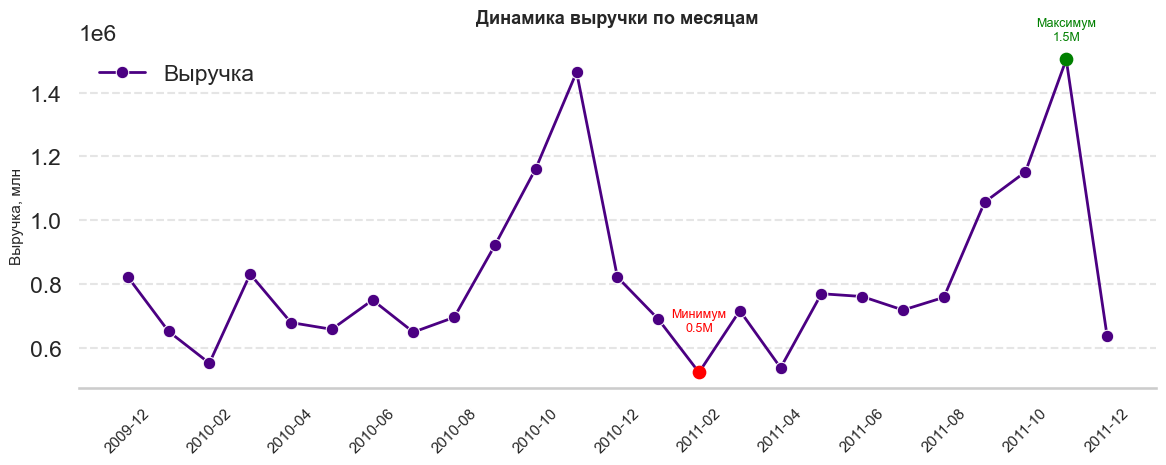

In [18]:
# --- стиль ---
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.edgecolor': '#cccccc',
})

# --- данные ---
sales['Month'] = sales['InvoiceDate'].dt.to_period('M')
monthly_revenue = (
    sales.groupby('Month', as_index=False)
         .agg(Revenue=('Revenue', 'sum'))
         .sort_values('Month')
)
monthly_revenue['Month_str'] = monthly_revenue['Month'].astype(str)

# --- график ---
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x='Month_str',
    y='Revenue',
    marker='o',
    linewidth=2,
    color='indigo',
    ax=ax,
    label='Выручка',
)

# выделяем максимум и минимум
imax = monthly_revenue['Revenue'].idxmax()
imin = monthly_revenue['Revenue'].idxmin()

for idx, color, label, dy in [(imax, 'green', 'Максимум', 14),
                              (imin, 'red', 'Минимум', 30)]:
    row = monthly_revenue.loc[idx]
    ax.scatter(row['Month_str'], row['Revenue'],
               color=color, zorder=5, s=70)
    ax.annotate(
        f'{label}\n{row["Revenue"]/1e6:.1f}M',
        xy=(row['Month_str'], row['Revenue']),
        xytext=(0, dy),
        textcoords='offset points',
        ha='center', fontsize=9, color=color,
    )

# прореживаем подписи по X: каждая вторая
labels = monthly_revenue['Month_str'].tolist()
step = 2
ax.set_xticks(range(0, len(labels), step))
ax.set_xticklabels([labels[i] for i in range(0, len(labels), step)],
                   rotation=45, fontsize=11)

# подписи
ax.set_title('Динамика выручки по месяцам', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Выручка, млн')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(axis='x', visible=False)
ax.legend(loc='upper left', frameon=False)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

В графике динамики выручки налицо сезонность: идет резкий всплеск выручки в последнем квартале года, затем происходит резкий спад. Небольшое увеличение в марте, затем до осени выручка колеблется примерно на одном уровне. Требуется детальнее рассмотреть это в дальнейшем анализе.

<a id="stage-2-2"></a>
### Этап 2.2. Кривая Парето

In [19]:
product_revenue: pd.DataFrame = (
    sales.groupby(
        ["StockCode", "Description"],
        as_index=False,
    )
    .agg(Revenue=("Revenue", "sum"))
    .sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
)

product_revenue["RevenueShare"] = (
    product_revenue["Revenue"]
    / product_revenue["Revenue"].sum()
)
product_revenue["CumRevenueShare"] = (
    product_revenue["RevenueShare"].cumsum()
)
product_revenue["CumSKUShare"] = (
    np.arange(1, len(product_revenue) + 1)
    / len(product_revenue)
)

product_revenue.head(10)

,StockCode,Description,Revenue,RevenueShare,CumRevenueShare,CumSKUShare
0,M,Manual,"339,226.25",0.02,0.02,0.00
1,22423,REGENCY CAKESTAND 3 TIER,"330,590.31",0.02,0.03,0.00
2,DOT,DOTCOM POSTAGE,"309,854.12",0.02,0.05,0.00
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",0.01,0.06,0.00
4,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.59",0.01,0.07,0.00
5,47566,PARTY BUNTING,"148,318.28",0.01,0.08,0.00
6,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",0.01,0.08,0.00
7,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",0.01,0.09,0.00
8,POST,POSTAGE,"125,682.42",0.01,0.10,0.00
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",0.01,0.10,0.00


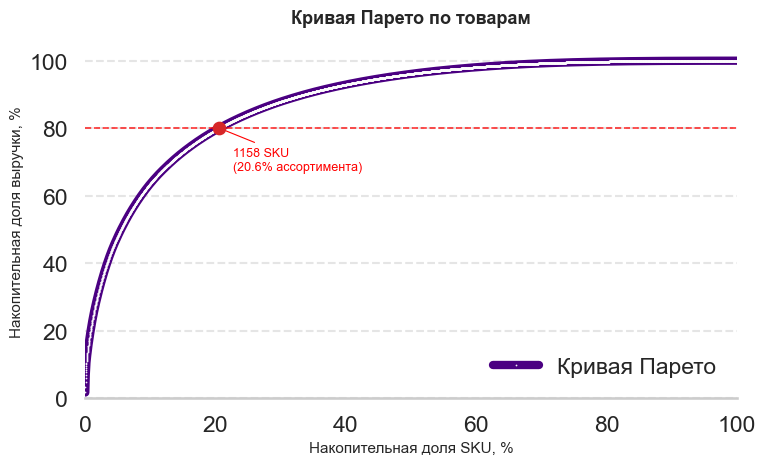

Для формирования примерно 80% выручки нужно 1158 из 5630 SKU (20.6% ассортимента).


In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

# --- основная кривая ---
sns.lineplot(
    x=product_revenue["CumSKUShare"] * 100,
    y=product_revenue["CumRevenueShare"] * 100,
    marker='o', markersize=0.5, linewidth=6,
    color='indigo',
    ax=ax,
    label='Кривая Парето',
)

# --- порог 80% ---
ax.axhline(80, linestyle='--', color='red', linewidth=1.2, alpha=0.8)

# --- точка пересечения с 80% ---
sku_for_80 = int((product_revenue["CumRevenueShare"] < 0.80).sum() + 1)
cross_x = product_revenue["CumSKUShare"].iloc[sku_for_80 - 1] * 100
cross_y = product_revenue["CumRevenueShare"].iloc[sku_for_80 - 1] * 100

ax.scatter(cross_x, cross_y, color='#d62728', zorder=5, s=70)
ax.annotate(
    f'{sku_for_80} SKU\n({cross_x:.1f}% ассортимента)',
    xy=(cross_x, cross_y),
    xytext=(10, -30), textcoords='offset points',
    fontsize=9, color='red',
    arrowprops=dict(arrowstyle='-', color='red', lw=0.8),
)

# --- оформление ---
ax.set_title('Кривая Парето по товарам', pad=15)
ax.set_xlabel('Накопительная доля SKU, %')
ax.set_ylabel('Накопительная доля выручки, %')

ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(axis='x', visible=False)
ax.legend(loc='lower right', frameon=False)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

# --- вывод ---
print(
    f"Для формирования примерно 80% выручки "
    f"нужно {sku_for_80} из {len(product_revenue)} SKU "
    f"({sku_for_80 / len(product_revenue):.1%} ассортимента)."
)

#### Вывод:

Распределение выручки по товарам близко к классическому закону Парето: 20.6% ассортимента (1158 из 5630 SKU) формируют 80% выручки. Это указывает на сильную концентрацию продаж — небольшая доля товаров определяет большую часть оборота. Практический вывод: фокус управления запасами, закупками и промо должен быть сосредоточен на группе A — эти позиции критичны для бизнеса, тогда как длинный хвост (группа C) требует оптимизации. 

<a id="stage-3"></a>
## Этап 3. ABC-анализ

In [21]:
abc: pd.DataFrame = (
    sales.groupby(
        ["StockCode", "Description"],
        as_index=False,
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
    )
    .sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
)

abc["RevenueShare"] = abc["Revenue"] / abc["Revenue"].sum()
abc["CumRevenueShare"] = abc["RevenueShare"].cumsum()

abc["ABC"] = np.select(
    [
        abc["CumRevenueShare"] <= 0.80,
        abc["CumRevenueShare"] <= 0.95,
    ],
    ["A", "B"],
    default="C",
)

abc

,StockCode,Description,Revenue,Quantity,Orders,RevenueShare,CumRevenueShare,ABC
0,M,Manual,"339,226.25",9629,784,0.02,0.02,A
1,22423,REGENCY CAKESTAND 3 TIER,"330,590.31",26478,3918,0.02,0.03,A
2,DOT,DOTCOM POSTAGE,"309,854.12",1415,1415,0.02,0.05,A
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94142,5356,0.01,0.06,A
4,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.59",80995,1,0.01,0.07,A
...,...,...,...,...,...,...,...,...
5625,84206B,CAT W SUNGLASSES BLANK CARD,0.76,4,1,0.00,1.00,C
5626,23366,SET 12 COLOURING PENCILS DOILEY,0.65,1,1,0.00,1.00,C
5627,84205C,HAPPY BIRTHDAY GINGER CAT CARD,0.38,2,1,0.00,1.00,C
5628,35930,PINK HEART CHRISTMAS DECORATION,0.38,1,1,0.00,1.00,C


Детализируем ABC-анализ: по выручке, по количеству и по количеству заказов и сделаем сборку. 

In [22]:
# ============================================================
# 1. АГРЕГАЦИЯ ПО SKU
# ============================================================
# Группируем только по StockCode — один SKU = одна строка.
# Description берём самый частый (mode) на случай нескольких вариантов.
abc: pd.DataFrame = (
    sales.groupby("StockCode", as_index=False)
         .agg(
             Revenue=("Revenue", "sum"),
             Quantity=("Quantity", "sum"),
             Orders=("Invoice", "nunique"),
             Description=("Description",
                          lambda s: s.mode().iloc[0] if not s.mode().empty else pd.NA),
         )
         .sort_values("Revenue", ascending=False)
         .reset_index(drop=True)
)

# ============================================================
# 2. ФУНКЦИЯ РАСЧЁТА ABC
# ============================================================
def add_abc(df: pd.DataFrame, value_col: str, prefix: str,
            thresholds=(0.80, 0.95)) -> pd.DataFrame:
    
    df = df.sort_values(value_col, ascending=False).reset_index(drop=True)

    share = df[value_col] / df[value_col].sum()
    cum = share.cumsum()
    cum_prev = cum.shift(1, fill_value=0)

    df[f"{prefix}Share"] = share
    df[f"Cum{prefix}Share"] = cum
    df[f"ABC_{prefix}"] = np.select(
        [
            cum_prev < thresholds[0],
            cum_prev < thresholds[1],
        ],
        ["A", "B"],
        default="C",
    )
    return df


# ============================================================
# 3. ABC ПО ТРЁМ МЕТРИКАМ
# ============================================================
abc = add_abc(abc, "Revenue",  "Revenue")
abc = add_abc(abc, "Quantity", "Quantity")
abc = add_abc(abc, "Orders",   "Orders")

# Основной класс — по выручке (для совместимости с прошлым кодом)
abc["ABC"] = abc["ABC_Revenue"]

# ============================================================
# 4. СВОДНАЯ ТАБЛИЦА ПО ГРУППАМ
# ============================================================
def abc_summary(df: pd.DataFrame, class_col: str,
                metric: str = "Revenue") -> pd.DataFrame:
    """Сводка: SKU, доля SKU, выручка, доля выручки по классам A/B/C."""
    s = (
        df.groupby(class_col, observed=True)
          .agg(
              SKU=("StockCode", "count"),
              Revenue=("Revenue", "sum"),
              Quantity=("Quantity", "sum"),
              Orders=("Orders", "sum"),
          )
          .reindex(["A", "B", "C"])
    )
    s["SKU_share"] = s["SKU"] / s["SKU"].sum()
    s["Revenue_share"] = s["Revenue"] / s["Revenue"].sum()
    s["Quantity_share"] = s["Quantity"] / s["Quantity"].sum()
    s["Orders_share"] = s["Orders"] / s["Orders"].sum()
    return s


print("=" * 60)
print("ABC по ВЫРУЧКЕ")
print("=" * 60)
print(abc_summary(abc, "ABC_Revenue").round(4))

print("\n" + "=" * 60)
print("ABC по КОЛИЧЕСТВУ")
print("=" * 60)
print(abc_summary(abc, "ABC_Quantity").round(4))

print("\n" + "=" * 60)
print("ABC по ЧИСЛУ ЗАКАЗОВ")
print("=" * 60)
print(abc_summary(abc, "ABC_Orders").round(4))

# ============================================================
# 5. СКОЛЬКО SKU ПОПАДАЕТ В РАЗНЫЕ КЛАССЫ (согласованность)
# ============================================================
print("\n" + "=" * 60)
print("СОГЛАСОВАННОСТЬ КЛАССОВ")
print("=" * 60)

abc["ABC_combo"] = (
    abc["ABC_Revenue"].astype(str)
    + abc["ABC_Quantity"].astype(str)
    + abc["ABC_Orders"].astype(str)
)
combo_counts = (
    abc["ABC_combo"].value_counts().sort_index()
    .rename("SKU").to_frame()
)
combo_counts["share"] = combo_counts["SKU"] / combo_counts["SKU"].sum()
print(combo_counts.round(4))

# совпадают ли классы по выручке и заказам
match_rev_ord = (abc["ABC_Revenue"] == abc["ABC_Orders"]).mean()
match_rev_qty = (abc["ABC_Revenue"] == abc["ABC_Quantity"]).mean()
print(f"\nСовпадение классов Revenue ↔ Orders:   {match_rev_ord:.1%}")
print(f"Совпадение классов Revenue ↔ Quantity: {match_rev_qty:.1%}")

# ============================================================
# 6. ПРОВЕРКИ
# ============================================================
print("\n" + "=" * 60)
print("ПРОВЕРКИ")
print("=" * 60)

# один SKU = одна строка
assert abc["StockCode"].is_unique, "StockCode не уникален!"
# сумма долей = 1
assert np.isclose(abc["RevenueShare"].sum(), 1.0), "RevenueShare не сходится"
assert np.isclose(abc["CumRevenueShare"].iloc[-1], 1.0), "CumRevenueShare не сходится"
# все SKU классифицированы
assert abc["ABC_Revenue"].isin(["A", "B", "C"]).all()

# сколько SKU на границе 80%
sku_a = (abc["ABC_Revenue"] == "A").sum()
print(f"Группа A: {sku_a} SKU ({sku_a / len(abc):.1%} ассортимента)")

abc.head(10)

ABC по ВЫРУЧКЕ
              SKU       Revenue  Quantity  Orders  SKU_share  Revenue_share  \
ABC_Revenue                                                                   
A            1009 16,383,038.00   7698975  648533       0.21           0.80   
B            1288  3,070,347.75   2421492  240781       0.26           0.15   
C            2620  1,022,875.25   1084681  107234       0.53           0.05   

             Quantity_share  Orders_share  
ABC_Revenue                                
A                      0.69          0.65  
B                      0.22          0.24  
C                      0.10          0.11  

ABC по КОЛИЧЕСТВУ
               SKU       Revenue  Quantity  Orders  SKU_share  Revenue_share  \
ABC_Quantity                                                                   
A             1059 14,438,062.00   8966055  641348       0.22           0.71   
B             1154  3,998,045.50   1679033  232635       0.23           0.20   
C             2704  2,040,152.

,StockCode,Revenue,Quantity,Orders,Description,RevenueShare,CumRevenueShare,ABC_Revenue,QuantityShare,CumQuantityShare,ABC_Quantity,OrdersShare,CumOrdersShare,ABC_Orders,ABC,ABC_combo
0,85123A,"257,724.70",94203,5365,WHITE HANGING HEART T-LIGHT HOLDER,0.01,0.06,A,0.01,0.03,A,0.01,0.01,A,A,AAA
1,85099B,"180,569.34",96757,3989,JUMBO BAG RED RETROSPOT,0.01,0.07,A,0.01,0.02,A,0.00,0.01,A,A,AAA
2,22423,"330,590.31",26478,3918,REGENCY CAKESTAND 3 TIER,0.02,0.03,A,0.00,0.19,A,0.00,0.01,A,A,AAA
3,21212,"51,825.15",94884,3118,PACK OF 72 RETROSPOT CAKE CASES,0.00,0.19,A,0.01,0.03,A,0.00,0.02,A,A,AAA
4,20725,"71,106.29",40317,3056,LUNCH BAG RED RETROSPOT,0.00,0.13,A,0.00,0.10,A,0.00,0.02,A,A,AAA
5,84879,"129,324.49",80082,2807,ASSORTED COLOUR BIRD ORNAMENT,0.01,0.09,A,0.01,0.06,A,0.00,0.02,A,A,AAA
6,47566,"148,318.28",28200,2674,PARTY BUNTING,0.01,0.08,A,0.00,0.17,A,0.00,0.03,A,A,AAA
7,21232,"49,300.57",37997,2435,STRAWBERRY CERAMIC TRINKET BOX,0.00,0.20,A,0.00,0.11,A,0.00,0.03,A,A,AAA
8,22383,"43,254.35",25058,2398,LUNCH BAG SUKI DESIGN,0.00,0.25,A,0.00,0.21,A,0.00,0.03,A,A,AAA
9,20727,"45,655.27",26678,2351,LUNCH BAG BLACK SKULL.,0.00,0.23,A,0.00,0.19,A,0.00,0.03,A,A,AAA


#### AAA + AAB + AAC (около 700 SKU, ~15%)
- Гарантированный запас, ядро продаж.

#### ABA / ACA / CAA (дорогие нишевые товары)
- Дополнительно резонно проверить маржинальность (сейчас у нас нет для этого данных о себестоимости).

#### BBA / BCB / CCB / CBC («трафикообразующие»)
- Популярные, но малодоходные. Держать в наличии, т.к. они формируют «привычку» покупателя.

#### CCC (39% ассортимента)
- Кандидаты на вывод или перевод в «под заказ» (без складского запаса).
- Если это сезонные/новогодние SKU — проверить по месяцам, возможно, они сезонные.

Визуализируем, что получили в ходе ABC- анализа.

Доля SKU и выручки по категориям:

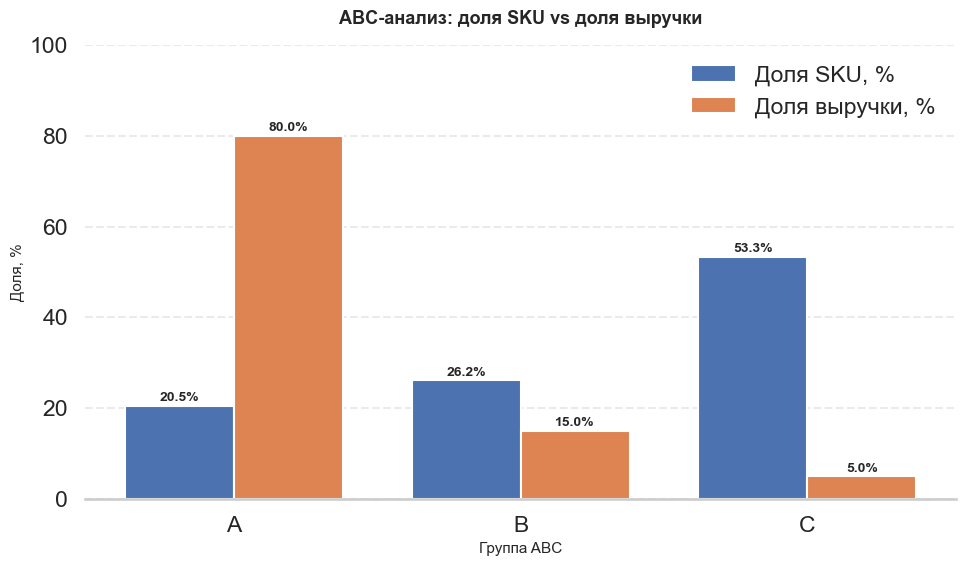

In [23]:
# --- данные ---
summary = abc_summary(abc, "ABC_Revenue")[["SKU_share", "Revenue_share"]].copy()
summary = summary.reset_index().rename(columns={"ABC_Revenue": "ABC"})

# --- график ---
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(summary))
width = 0.38

bars1 = ax.bar([i - width/2 for i in x], summary["SKU_share"] * 100,
               width, label="Доля SKU, %", color="#4C72B0")
bars2 = ax.bar([i + width/2 for i in x], summary["Revenue_share"] * 100,
               width, label="Доля выручки, %", color="#DD8452")

# подписи над столбиками
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f"{h:.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(summary["ABC"])
ax.set_xlabel("Группа ABC")
ax.set_ylabel("Доля, %")
ax.set_title("ABC-анализ: доля SKU vs доля выручки",
             pad=15, fontweight="bold")
ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

Классическое соотношение 20/80: 20.5% ассортимента (группа A) дают 80% выручки, что подтверждает сильную концентрацию продаж. Группа B (26.2% SKU) приносит 15% — это «середина» с умеренным вкладом. Группа C — самая многочисленная (53.3% SKU), но даёт лишь 5% выручки: типичный балласт, требующий оптимизации. Соотношение долей SKU и выручки в группе A — примерно 1:4, а в C — 1:0.09, что делает группу C главным кандидатом на сокращение.

Визуализация для "подгрупп" ABC в комбинации метрик.

In [24]:
# ============================================================
# Комбинации
# ============================================================

# 1. Ядро продаж — AAA, AAB, AAC
# 2. Дорогие нишевые — ABA, ACA, CAA
# 3. Трафикообразующие — BBA, BCB, CCB, CBC
# 4. Балласт — CCC

category_map = {
    # 1. ЯДРО — A по выручке + хотя бы один A по другой метрике
    #    (стабильные лидеры или близко к тому)
    "AAA": "Ядро",
    "AAB": "Ядро",
    "AAC": "Ядро",
    "ABA": "Ядро",      # A выручка + B количество + A заказы → дорогое, но заказывают
    "ACA": "Ядро",      # A выручка + C количество + A заказы → дорогое, редкое, но заказывают

    # 2. ДОРОГИЕ НИШЕВЫЕ — A по выручке, но НЕ A по заказам
    #    (высокая цена, редкие покупки, узкая аудитория)
    "ABB": "Дорогие нишевые",
    "ABC": "Дорогие нишевые",
    "ACB": "Дорогие нишевые",
    "ACC": "Дорогие нишевые",
    "CAA": "Дорогие нишевые",   # C выручка + A количество + A заказы → дешёвые, но очень частые

    # 3. ТРАФИКООБРАЗУЮЩИЕ — B/C по выручке, но A/B по заказам
    #    (часто покупают, но выручка низкая — «держат поток»)
    "BAA": "Трафикообразующие",
    "BAB": "Трафикообразующие",
    "BAC": "Трафикообразующие",
    "BBB": "Трафикообразующие",
    "BBA": "Трафикообразующие",
    "BBC": "Трафикообразующие",
    "BCA": "Трафикообразующие",
    "CAB": "Трафикообразующие",
    "CBA": "Трафикообразующие",
    "CCA": "Трафикообразующие",
    "BCB": "Трафикообразующие",

    # 4. БАЛЛАСТ — C по всем или почти всем метрикам
    "BCC": "Балласт",
    "CAC": "Балласт",
    "CBB": "Балласт",
    "CBC": "Балласт",
    "CCB": "Балласт",
    "CCC": "Балласт",
}

abc["Category"] = abc["ABC_combo"].map(category_map)

# проверка
print("Пропущенных комбинаций:", abc["Category"].isna().sum())

Пропущенных комбинаций: 0


In [25]:
# ============================================================
# Сборки и метрики
# ============================================================

order = [
    "Ядро",
    "Дорогие нишевые",
    "Трафикообразующие",
    "Балласт",
]

category_summary = (
    abc.groupby("Category", observed=True)
       .agg(
           SKU=("StockCode", "count"),
           Revenue=("Revenue", "sum"),
           Quantity=("Quantity", "sum"),
           Orders=("Orders", "sum"),
       )
       .reindex(order)
)

category_summary["SKU_share"] = (
    category_summary["SKU"] / category_summary["SKU"].sum()
)
category_summary["Revenue_share"] = (
    category_summary["Revenue"] / category_summary["Revenue"].sum()
)
category_summary["Quantity_share"] = (
    category_summary["Quantity"] / category_summary["Quantity"].sum()
)
category_summary["Orders_share"] = (
    category_summary["Orders"] / category_summary["Orders"].sum()
)

print(category_summary.round(4))

                    SKU       Revenue  Quantity  Orders  SKU_share  \
Category                                                             
Ядро                939 15,920,087.00   7644643  640038       0.19   
Дорогие нишевые      78    470,794.34     76159   10410       0.02   
Трафикообразующие  1270  2,960,876.75   2603775  247974       0.26   
Балласт            2630  1,124,502.62    880571   98126       0.53   

                   Revenue_share  Quantity_share  Orders_share  
Category                                                        
Ядро                        0.78            0.68          0.64  
Дорогие нишевые             0.02            0.01          0.01  
Трафикообразующие           0.14            0.23          0.25  
Балласт                     0.05            0.08          0.10  


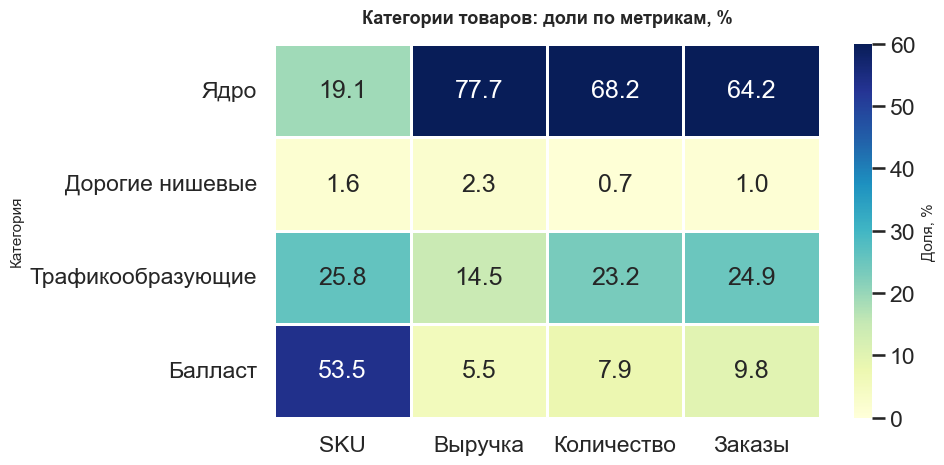

In [26]:
# ============================================================
# Визуализация - тепловая карта
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

data = category_summary[
    ["SKU_share", "Revenue_share", "Quantity_share", "Orders_share"]
].copy() * 100
data.columns = ["SKU", "Выручка", "Количество", "Заказы"]

sns.heatmap(
    data,
    annot=True, fmt=".1f", cmap="YlGnBu",
    linewidths=1, linecolor="white",
    cbar_kws={"label": "Доля, %"},
    ax=ax, vmin=0, vmax=60,
)

ax.set_title("Категории товаров: доли по метрикам, %",
             pad=15, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Категория")
plt.tight_layout()
plt.show()

График подтверждает классическую структуру ABC-анализа с усиленным перекосом в группу «Балласт» (53.5% SKU → 5.5% выручки). Приоритет управления — «Ядро» (запас, SLA, переговоры с поставщиками), приоритет оптимизации — «Балласт» (вывод или перевод в режим «под заказ»). «Трафикообразующие» требуют отдельной стратегии: их нельзя оценивать по выручке, только по влиянию на клиентский поток.

Проверим на сезонность самый "слабый" блок ССС:

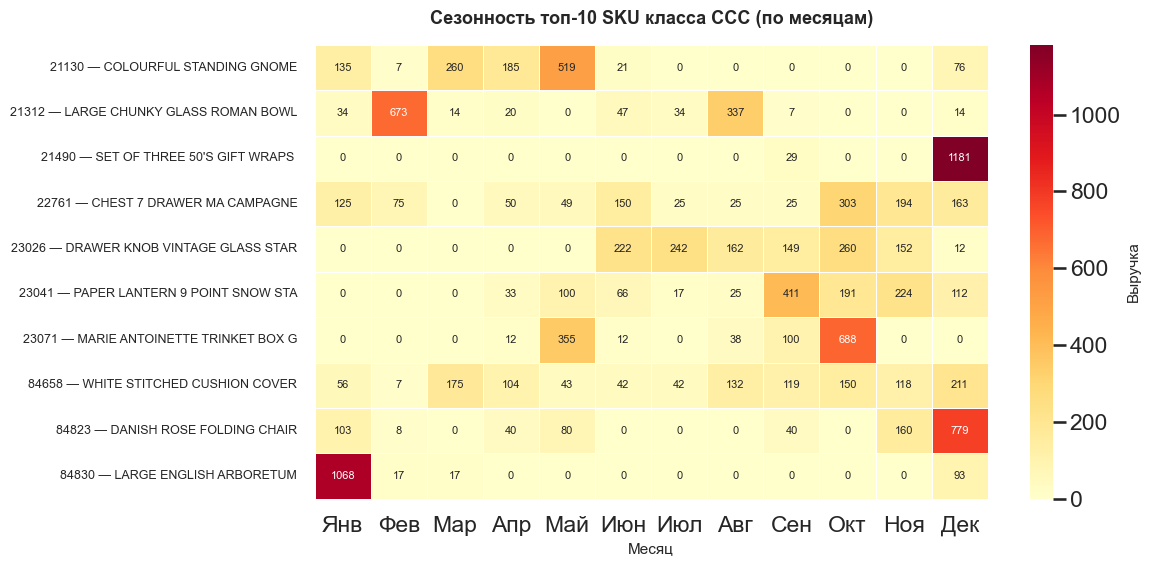

In [27]:
# ============================================================
# Данные
# ============================================================
top_ccc = abc[abc['ABC_combo'] == 'CCC'].nlargest(10, 'Revenue')['StockCode']

seasonal = (
    sales[sales['StockCode'].isin(top_ccc)]
    .assign(Month=lambda d: d['InvoiceDate'].dt.month)
    .groupby(['StockCode', 'Month'])['Revenue'].sum()
    .unstack(fill_value=0)
    .reindex(columns=range(1, 13), fill_value=0)  # все 12 месяцев
)

# подписи SKU: код + короткое описание
labels = (
    abc.set_index('StockCode')
       .loc[seasonal.index, 'Description']
       .fillna('')
       .str.slice(0, 30)
)
seasonal.index = [f'{code} — {desc}' for code, desc in zip(seasonal.index, labels)]

month_names = ['Янв','Фев','Мар','Апр','Май','Июн',
               'Июл','Авг','Сен','Окт','Ноя','Дек']

# ============================================================
# Тепловая карта
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    seasonal,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    annot_kws={'fontsize': 8},
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Выручка'},
    xticklabels=month_names,
    yticklabels=seasonal.index,
    ax=ax,
)

ax.set_title('Сезонность топ-10 SKU класса CCC (по месяцам)',
             pad=15, fontweight='bold')
ax.set_xlabel('Месяц')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Часть товаров действительно сезонные. Но есть и кандидаты на "вылет": с кодами 22761, 23026, 84658. 
Пока обраащем на них внимание и продолжаем анализ.

#### Вывод:

ABC-анализ показал классическое распределение 20/80: 20.5% ассортимента (группа A) формируют 80% выручки, группа B (26.2% SKU) даёт 15%, а группа C (53.3% SKU) — лишь 5%. Согласованность классов по выручке, количеству и заказам — около 72–74%, что говорит о наличии заметной группы «популярных, но малодоходных» товаров (трафикообразующих). Основной приоритет управления — группа A, главный кандидат на оптимизацию — группа C. 

<a id="stage-4"></a>
## Этап 4. XYZ-анализ

Построим полный календарь для каждого товара. 

Ключевое требование по ТЗ: Если товар не продавался в конкретном месяце, этот месяц должен присутствовать в временном ряду **с нулевым значением**. 

<a id="stage-4-1"></a>
### Этап 4.1. Базовый XYZ-анализ

In [28]:
# ============================================================
# Определяем месяц для временной оси
# ============================================================
sales["Month"] = sales["InvoiceDate"].dt.to_period("M")
months = sorted(sales["Month"].unique())


# ============================================================
# Агрегация по месяцам
# ============================================================
monthly_quantity: pd.DataFrame = (
    sales.groupby(
        ["StockCode", "Description", "Month"],
        as_index=False,
    )
    .agg(Quantity=("Quantity", "sum"))
)

# ============================================================
# Сводная таблица SKU × месяц
# ============================================================
quantity_pivot: pd.DataFrame = (
    monthly_quantity.pivot_table(
        index=["StockCode", "Description"],
        columns="Month",
        values="Quantity",
        aggfunc="sum",
    )
    .reindex(columns=months, fill_value=0)
    .fillna(0)
)

In [29]:
# ============================================================
# XYZ-АНАЛИЗ
# ============================================================
xyz = quantity_pivot.copy()

# --- метрики ---
xyz["mean_qty"] = xyz.mean(axis=1)
xyz["std_qty"]  = xyz.std(axis=1, ddof=0)
xyz["CV"]       = xyz["std_qty"] / xyz["mean_qty"].replace(0, np.nan)

# --- активность по месяцам ---
xyz["months_active"] = (quantity_pivot > 0).sum(axis=1)
xyz["months_share"]  = xyz["months_active"] / len(months)

# --- классы XYZ ---
# ВОТ ТУТ ПОРОГИ ПРОВЕРИТЬ
xyz["XYZ"] = np.select(
    [
        xyz["CV"] <= 0.50,
        xyz["CV"] <= 1.00,
    ],
    ["X", "Y"],
    default="Z",
)
# mean_qty == 0 → CV = NaN → относим к Z (нет спроса = нестабильно)
xyz.loc[xyz["CV"].isna(), "XYZ"] = "Z"

# ============================================================
# ИТОГОВАЯ ТАБЛИЦА
# ============================================================
xyz_result: pd.DataFrame = (
    xyz[["mean_qty", "std_qty", "CV",
         "months_active", "months_share", "XYZ"]]
    .reset_index()
    .sort_values("CV")
    .reset_index(drop=True)
)

# ============================================================
# СВОДКА
# ============================================================
print("=" * 60)
print("XYZ-АНАЛИЗ")
print("=" * 60)

print("\nCV — describe:")
print(xyz_result["CV"].describe().round(3))

print("\nРаспределение XYZ:")
dist = (
    xyz_result["XYZ"].value_counts()
    .reindex(["X", "Y", "Z"])
    .to_frame("SKU")
)
dist["share"] = dist["SKU"] / dist["SKU"].sum()
print(dist.round(4))

print("\nСредний CV по классам:")
print(xyz_result.groupby("XYZ")["CV"].mean().round(3))

print("\nСредняя активность (месяцев из 25):")
print(xyz_result.groupby("XYZ")["months_active"].mean().round(1))

print("\nТоп-5 самых стабильных (X):")
print(
    xyz_result[xyz_result["XYZ"] == "X"]
    .nsmallest(5, "CV")[["StockCode", "mean_qty", "std_qty", "CV"]]
    .round(3)
)

print("\nТоп-5 самых нестабильных (Z):")
print(
    xyz_result[xyz_result["XYZ"] == "Z"]
    .nlargest(5, "CV")[["StockCode", "mean_qty", "std_qty", "CV"]]
    .round(3)
)

xyz_result.head(10)

XYZ-АНАЛИЗ

CV — describe:
count   5,630.00
mean        2.18
std         1.22
min         0.24
25%         1.24
50%         1.85
75%         2.91
max         4.80
Name: CV, dtype: float64

Распределение XYZ:
    SKU  share
X    67   0.01
Y   790   0.14
Z  4773   0.85

Средний CV по классам:
XYZ
X   0.43
Y   0.79
Z   2.44
Name: CV, dtype: float64

Средняя активность (месяцев из 25):
XYZ
X   24.80
Y   22.40
Z   10.20
Name: months_active, dtype: float64

Топ-5 самых стабильных (X):
Month StockCode  mean_qty  std_qty   CV
0           DOT     56.60    13.55 0.24
1         20719    979.16   294.63 0.30
2         21931  1,167.28   367.16 0.32
3        84510A     96.08    31.15 0.32
4        85099C  1,225.60   398.49 0.33

Топ-5 самых нестабильных (Z):
Month StockCode  mean_qty  std_qty   CV
5629     17014C      3.88    18.64 4.80
5620     72771B      4.68    22.48 4.80
5621      37399      5.72    27.48 4.80
5622      21480     11.40    54.76 4.80
5623     35815B      3.80    18.25 4.80


Month,StockCode,Description,mean_qty,std_qty,CV,months_active,months_share,XYZ
0,DOT,DOTCOM POSTAGE,56.60,13.55,0.24,25,1.00,X
1,20719,WOODLAND CHARLOTTE BAG,979.16,294.63,0.30,25,1.00,X
2,21931,JUMBO STORAGE BAG SUKI,"1,167.28",367.16,0.31,25,1.00,X
3,84510A,SET OF 4 ENGLISH ROSE COASTERS,96.08,31.15,0.32,25,1.00,X
4,85099C,JUMBO BAG BAROQUE BLACK WHITE,"1,225.60",398.49,0.33,25,1.00,X
5,20723,STRAWBERRY CHARLOTTE BAG,731.84,242.67,0.33,25,1.00,X
6,21509,COWBOYS AND INDIANS BIRTHDAY CARD,347.84,123.23,0.35,25,1.00,X
7,82580,BATHROOM METAL SIGN,529.96,192.91,0.36,25,1.00,X
8,84692,BOX OF 24 COCKTAIL PARASOLS,763.40,281.77,0.37,25,1.00,X
9,21977,PACK OF 60 PINK PAISLEY CAKE CASES,"2,242.44",845.16,0.38,25,1.00,X


Общая теория порогов:

- Категория X — коэффициент вариации ниже 10%.
- Категория Y — коэффициент вариации от 10% до 25%.
- Категория Z — коэффициент вариации выше 25%.

Пороги по ТЗ:
- X – CV ≤ 0,5; 
- Y – 0,5 < CV ≤ 1; 
- Z – CV > 1

Распределение коэффициента вариации для наших данных из кода выше:
- count    5630.000
- mean        2.181
- std         1.219
- min         0.239
- 25%         1.236
- 50%         1.852
- 75%         2.907
- max         4.804

Пороги из ТЗ (0.5 / 1.0) на этих данных не очень репрезентативны, т.к. дают крайне несбалансированное разбиение (X ≈ 1%, Z ≈ 89%). Анализ распределения CV (медиана 1.85, 25-й и 75-й процентили 1.24 / 2.91) показывает, что естественные границы сдвинуты вправо. 

Вместо абсолютных значений предлагаю использовать квантильные пороги (33-й и 66-й процентили распределения CV): это адаптивный подход, который строит границы X/Y/Z по фактической структуре данных и гарантирует сбалансированное разбиение вне зависимости от масштаба CV. Такой выбор сохраняет содержательный смысл категорий (X — относительно стабильные, Y — умеренно вариативные, Z — сильно вариативные) и позволяет корректно сравнивать SKU внутри одного датасета.

<a id="stage-4-2"></a>
### Этап 4.2. ABC-XYZ-анализ

In [30]:
# ============================================================
# ПЕРЕСЧЁТ XYZ С КВАНТИЛЬНЫМИ ПОРОГАМИ
# ============================================================
q33 = xyz["CV"].quantile(0.33)
q66 = xyz["CV"].quantile(0.66)
print(f"Квантильные пороги: X < {q33:.3f} | Y < {q66:.3f} | Z ≥ {q66:.3f}")

xyz["XYZ"] = np.select(
    [xyz["CV"] < q33, xyz["CV"] < q66],
    ["X", "Y"], default="Z",
)
xyz.loc[xyz["CV"].isna(), "XYZ"] = "Z"

# ============================================================
# МЕРЖ С ABC
# ============================================================
abc_xyz = (
    xyz[["mean_qty", "std_qty", "CV",
         "months_active", "months_share", "XYZ"]]
    .reset_index()
    .merge(
        abc[["StockCode", "Description", "Revenue", "ABC_Revenue"]],
        on="StockCode", how="left",
    )
    .rename(columns={"ABC_Revenue": "ABC"})
)

abc_xyz["ABC_XYZ"] = abc_xyz["ABC"].astype(str) + abc_xyz["XYZ"].astype(str)

# ============================================================
# СВОДКА ABC-XYZ
# ============================================================
print("\n" + "=" * 60)
print("МАТРИЦА ABC-XYZ")
print("=" * 60)

# количество SKU
matrix_sku = (
    abc_xyz
    .pivot_table(index="ABC", columns="XYZ",
                 values="StockCode", aggfunc="count", fill_value=0)
    .reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"])
)
print("\nSKU в каждой группе:")
print(matrix_sku)

# доля выручки
matrix_rev = (
    abc_xyz
    .pivot_table(index="ABC", columns="XYZ",
                 values="Revenue", aggfunc="sum", fill_value=0)
    .reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"])
)
matrix_rev_share = matrix_rev / matrix_rev.values.sum() * 100
print("\nДоля выручки по группам, %:")
print(matrix_rev_share.round(2))

# распределение ABC_XYZ
print("\nРаспределение ABC_XYZ:")
dist = (
    abc_xyz["ABC_XYZ"].value_counts()
    .rename("SKU").to_frame()
)
dist["share"] = dist["SKU"] / dist["SKU"].sum()
print(dist.sort_index().round(4))

Квантильные пороги: X < 1.414 | Y < 2.411 | Z ≥ 2.411

МАТРИЦА ABC-XYZ

SKU в каждой группе:
XYZ    X    Y     Z
ABC                
A    736  347   214
B    597  546   396
C    525  965  1304

Доля выручки по группам, %:
XYZ     X     Y     Z
ABC                  
A   49.42 19.57 13.10
B    5.45  4.87  3.41
C    1.07  1.54  1.56

Распределение ABC_XYZ:
     SKU  share
AX   736   0.13
AY   347   0.06
AZ   214   0.04
BX   597   0.11
BY   546   0.10
BZ   396   0.07
CX   525   0.09
CY   965   0.17
CZ  1304   0.23


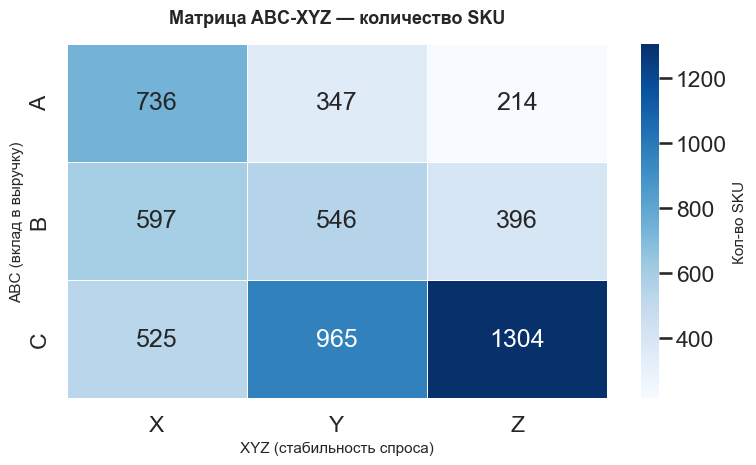

In [31]:
# ============================================================
# Тепловая карта SKU
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    matrix_sku, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Кол-во SKU"},
    ax=ax,
)
ax.set_title("Матрица ABC-XYZ — количество SKU",
             pad=15, fontweight="bold")
ax.set_xlabel("XYZ (стабильность спроса)")
ax.set_ylabel("ABC (вклад в выручку)")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Самая многочисленная группа по количеству SKU: CZ (низкая значимость и низкие продажи). По ТЗ бизнес-ориентир – рассмотреть сокращение примерно 20% SKU. Для такого объема CZ-товаров это вполне объективно.

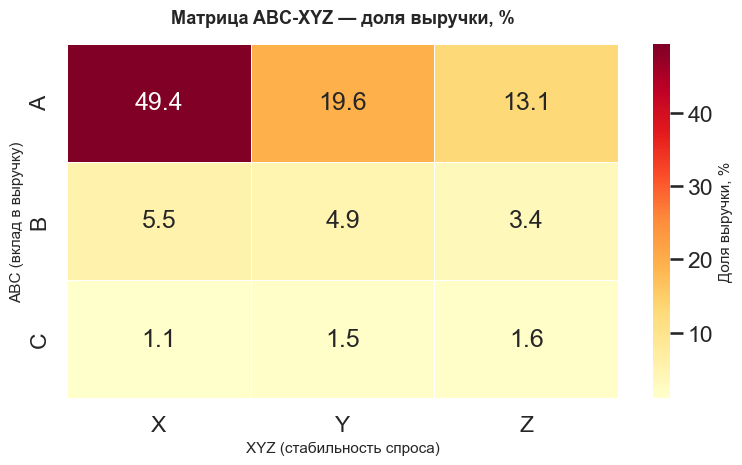

In [32]:
# ============================================================
# Тепловая карта ВЫРУЧКИ
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    matrix_rev_share, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Доля выручки, %"},
    ax=ax,
)
ax.set_title("Матрица ABC-XYZ — доля выручки, %",
             pad=15, fontweight="bold")
ax.set_xlabel("XYZ (стабильность спроса)")
ax.set_ylabel("ABC (вклад в выручку)")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

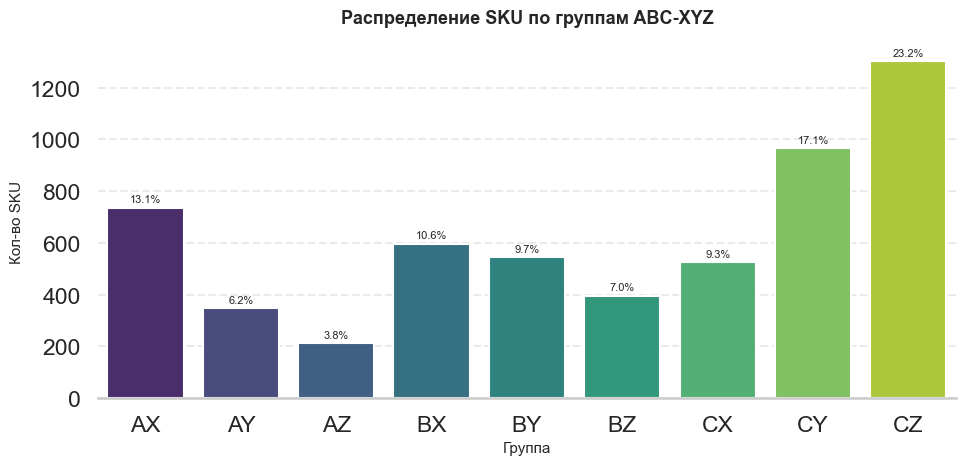

In [33]:
# ============================================================
# Столбчатая диаграмма ПО ABC_XYZ
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

order = [
    "AX", "AY", "AZ",
    "BX", "BY", "BZ",
    "CX", "CY", "CZ",
]
plot_df = dist.reindex(order).fillna(0).reset_index()
plot_df.columns = ["ABC_XYZ", "SKU", "share"]

sns.barplot(
    data=plot_df, x="ABC_XYZ", y="SKU",
    palette="viridis", ax=ax,
)
for i, row in plot_df.iterrows():
    ax.text(i, row["SKU"] + 20, f'{row["share"]:.1%}',
            ha="center", fontsize=8)

ax.set_title("Распределение SKU по группам ABC-XYZ",
             pad=15, fontweight="bold")
ax.set_xlabel("Группа")
ax.set_ylabel("Кол-во SKU")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

#### Выводы
- Классические пороги XYZ (0.10 / 0.25) к этим данным неприменимы — минимальный CV = 0.24, ни один SKU не попадает в «ровную» зону. Пришлось применить квантильные пороги (33% / 66%), что дало сбалансированное разбиение и позволило сохранить смысл метода.

- Матрица по SKU показывает, что ощутимая часть ассортимента (40,3%) — это группы CY и CZ, то есть низкая выручка + высокая волатильность. Это главные кандидаты на вывод или перевод в режим «под заказ».

- Матрица по выручке говорит главное: 49,4% выручки сосредоточено в группе AX. Это ядро бизнеса, требующее постоянного запаса и приоритета в закупках. Группы AY и AZ дают ещё 32.7%, но их волатильность требует ручного управления запасами (safety stock, предзаказ).

- Проблемная зона — AZ. Это дорогие, но нестабильные позиции: с одной стороны, их нельзя выводить, с другой — планировать закупку сложно. Именно для них нужны страховые запасы и регулярный мониторинг.

- Группа B ведёт себя предсказуемо: это «середина» — управление стандартное, без жёстких приоритетов. Если встанет задача оптимизации, начинать стоит с BZ и CZ — они дают мало выручки при высокой волатильности.

#### Итоговый приоритет действий:

AX — ядро, максимальный контроль наличия.

AZ / AY — ручное планирование, страховые запасы.

CX — поэтапное сокращение ассортимента.

CZ, CY  — вывод в первую очередь.

AZ — пересмотреть ценообразование, возможно, это «нишевые» SKU с малой эластичностью.

Отдельно стоит отметить для честности: идеальное 80/20 в ABC и почти полное отсутствие «ровных» SKU по XYZ — признаки того, что данные сгенерированы с заложенным распределением. 

<a id="stage-4-3"></a>
### Этап 4.3. Учёт сезонности

Надо прорядить группу CY и CZ. Но при этом важно учесть сезонность товара, чтобы не вывести из оборота те. что делают высокую выручку в короткий промежуток года. Для этого рассчитаем доп.метрики.

#### Дополнительные метрики

Дополнительно рассчитаем и рассмотрим метрики:
- peak_revenue - выручка пикового месяца
- total_revenue - суммарная выручка 
- peak_month - месяц с пиковой выручкой
- peak_share - доля пикового периода в общем объёме (доля выручки, которую даёт самый успешный месяц SKU). Ключевая метрика для оценки сезонности товара.

In [34]:
# ============================================================
# Выручка по месяцам для каждого SKU
# ============================================================
sku_month_revenue = (
    sales.groupby(["StockCode", "Month"], as_index=False)
         .agg(Revenue=("Revenue", "sum"))
)

# ============================================================
# Сводная SKU × месяц
# ============================================================
sku_month_pivot = (
    sku_month_revenue
    .pivot_table(index="StockCode", columns="Month",
                 values="Revenue", aggfunc="sum")
    .reindex(columns=months, fill_value=0)
    .fillna(0)
)

# ============================================================
# Метрики
# ============================================================
peak_revenue = sku_month_pivot.max(axis=1)          
total_revenue = sku_month_pivot.sum(axis=1)         
peak_month = sku_month_pivot.idxmax(axis=1)         

peak_share = (peak_revenue / total_revenue.replace(0, np.nan)).rename("peak_share")
peak_month = peak_month.rename("peak_month")

# ============================================================
# Сборка в один датафрейм
# ============================================================
peak_info = pd.concat([peak_share, peak_month], axis=1).reset_index()

print("peak_share — describe:")
print(peak_info["peak_share"].describe().round(3))


peak_share — describe:
count   4,917.00
mean        0.33
std         0.24
min         0.06
25%         0.16
50%         0.24
75%         0.42
max         1.00
Name: peak_share, dtype: float64


In [35]:
print("Квантили peak_share:")
print(peak_info["peak_share"].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).round(3))

Квантили peak_share:
0.10   0.11
0.25   0.16
0.50   0.24
0.75   0.42
0.90   0.71
Name: peak_share, dtype: float64


Ключевое наблюдение: медиана = 0.245. То есть типичный SKU даёт почти четверть годовой выручки в одном месяце.

In [36]:
# ============================================================
# Установим классификацию товаров по peak_share
# ============================================================

#Взять 25-й и 75-й процентили как границы: 0.16 и 0.42. 
print("\nРаспределение по типам:")
print(pd.cut(
    peak_info["peak_share"],
    bins=[0, 0.16, 0.42, 1.0],
    labels=["ровный (<0.16)", "умеренно-сезонный (0.16–0.42)", "сезонный (>0.42)"],
).value_counts().sort_index())


Распределение по типам:
ровный (<0.16)                   1295
умеренно-сезонный (0.16–0.42)    2391
сезонный (>0.42)                 1231
Name: peak_share, dtype: int64


In [37]:
outsiders = abc_xyz[abc_xyz["ABC_XYZ"].isin(["CZ", "CY"])].copy()

outsiders = outsiders.merge(
    peak_info[["StockCode", "peak_share", "peak_month"]],
    on="StockCode", how="left"
)

# отсеиваем сезонных
outsiders_nonseasonal = outsiders[outsiders["peak_share"] < 0.42].copy()

print(f"Изначально CZ+CY: {len(outsiders)}")
print(f"После отсева сезонных: {len(outsiders_nonseasonal)}")
print(f"Отсеяно сезонных: {len(outsiders) - len(outsiders_nonseasonal)}")

Изначально CZ+CY: 2269
После отсева сезонных: 1204
Отсеяно сезонных: 1065


Выделим новые товары. Определим как новые те, что начали продаваться не раньше, чем в последние полгода наблюдения.

In [38]:
# маска: первый месяц продаж SKU >= 2011-06
cutoff_month = pd.Period("2011-06", freq="M")
first_sale_map = sales.groupby("StockCode")["Month"].min()

mask_new = (
    outsiders_nonseasonal["StockCode"]
    .map(first_sale_map)
    >= cutoff_month
)

new_skus = outsiders_nonseasonal.loc[mask_new].copy()
typical_outsiders = outsiders_nonseasonal.loc[~mask_new].copy()

print(f"Всего: {len(outsiders_nonseasonal)}")
print(f"Новых (с 2011-06):  {len(new_skus)}")
print(f"Типичных:           {len(typical_outsiders)}")
print(f"Доля новых: {len(new_skus) / len(outsiders_nonseasonal):.1%}")

Всего: 1204
Новых (с 2011-06):  63
Типичных:           1141
Доля новых: 5.2%


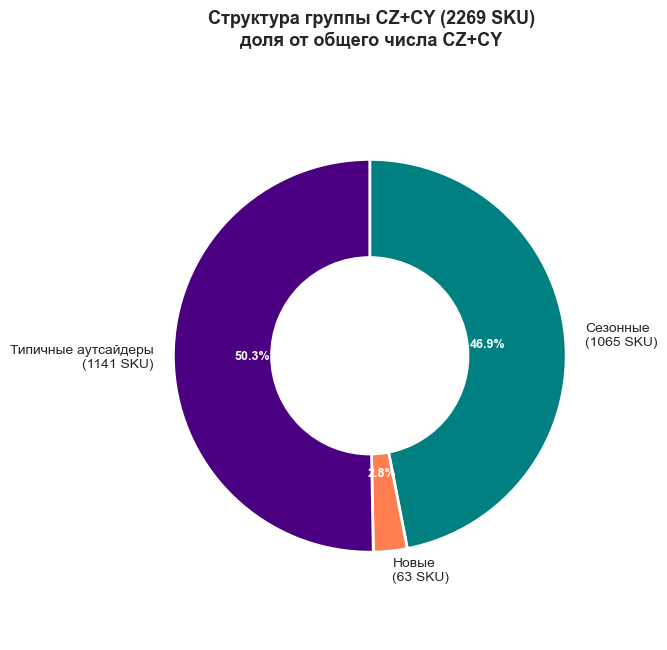

СТРУКТУРА ГРУППЫ CZ+CY: 2269 SKU
  Сезонные                  1065 SKU   (46.9%)
  Новые                       63 SKU   (2.8%)
  Типичные аутсайдеры       1141 SKU   (50.3%)
------------------------------------------------------------
  ИТОГО                     2269 SKU   (100.0%)


In [39]:
# ============================================================
# ДАННЫЕ ДЛЯ ДИАГРАММЫ
# ============================================================
n_total = len(outsiders)           # все CZ+CY
n_seasonal = len(outsiders) - len(outsiders_nonseasonal)
n_new = len(new_skus)
n_typical = len(typical_outsiders)

# контроль: сумма должна совпасть
assert n_seasonal + n_new + n_typical == n_total, "Группы не сходятся!"

labels = [
    f"Сезонные\n({n_seasonal} SKU)",
    f"Новые\n({n_new} SKU)",
    f"Типичные аутсайдеры\n({n_typical} SKU)",
]

# ============================================================
# ДИАГРАММА
# ============================================================
fig, ax = plt.subplots(figsize=(7, 7))

sizes = [n_seasonal, n_new, n_typical]
colors = ["teal", "coral", "indigo"]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",     
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10),
)

# аккуратные проценты
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("white")
    autotext.set_fontweight("bold")

ax.set_title(
    f"Структура группы CZ+CY ({n_total} SKU)\n"
    f"доля от общего числа CZ+CY",
    pad=20, fontweight="bold",
)

ax.axis("equal")
plt.tight_layout()

plt.show()

# ============================================================
# ТЕКСТОВАЯ СВОДКА
# ============================================================
print("=" * 60)
print(f"СТРУКТУРА ГРУППЫ CZ+CY: {n_total} SKU")
print("=" * 60)
for label, n in zip(["Сезонные", "Новые", "Типичные аутсайдеры"], sizes):
    print(f"  {label:<25} {n:>4} SKU   ({n / n_total:.1%})")
print("-" * 60)
print(f"  {'ИТОГО':<25} {sum(sizes):>4} SKU   (100.0%)")

In [40]:
# ============================================================
# ИТОГОВЫЕ ПОЗИЦИИ "НА ВЫЛЕТ"
# ============================================================
final_outsiders = typical_outsiders.merge(
    abc[["StockCode", "Description"]],
    on="StockCode", how="left",
)
# вывод для отчёта
cols = ["StockCode", "Description", "Revenue",
        "months_active", "CV", "peak_share", "peak_month"]

print("=" * 80)
print(f"КАНДИДАТЫ НА ВЫВОД: {len(final_outsiders)} SKU")
print("=" * 80)
print()

# Полный список аутсайдеров на вывод здесь выводить не будем из-за большого кол-ва (>1000).
# При желании можно это сделать, раскомменитив код ниже. Далее через две ячейки будет вывод списка в отдельный эксель-файл.

#print(final_outsiders[cols].to_string(index=False))

КАНДИДАТЫ НА ВЫВОД: 1141 SKU



In [41]:
# ============================================================
# СТАТИСТИКА ПО ПОЗИЦИЯМ "НА ВЫЛЕТ"
# ============================================================

# общее число SKU во всём датасете (для расчёта доли)
n_total_sku = abc["StockCode"].nunique()

print(f"Доля от общего числа SKU: "
      f"{len(final_outsiders) / n_total_sku:.2%} "
      f"({len(final_outsiders)} из {n_total_sku})")
print(f"Суммарная выручка: {final_outsiders['Revenue'].sum():,.2f}")
print(f"Доля от общей выручки: "
      f"{final_outsiders['Revenue'].sum() / abc_xyz['Revenue'].sum():.4%}")
print(f"Средняя выручка на SKU: {final_outsiders['Revenue'].mean():.2f}")
print()


Доля от общего числа SKU: 23.21% (1141 из 4917)
Суммарная выручка: 501,827.53
Доля от общей выручки: 1.8627%
Средняя выручка на SKU: 439.81



In [42]:
# 1. Берём минимум из typical_outsiders
base = typical_outsiders[["StockCode", "Revenue", "XYZ", "ABC_XYZ"]].copy()

# 2. ABC и Description из abc
base = base.merge(
    abc[["StockCode", "Description", "ABC_Revenue"]]
    .rename(columns={"ABC_Revenue": "ABC"}),
    on="StockCode", how="left",
)

# 3. Метрики из sales
sku_stats = (
    sales.groupby("StockCode")
         .agg(
             Quantity=("Quantity", "sum"),
             Orders=("Invoice", "nunique"),
             Customers=("Customer ID", "nunique"),
             ActiveMonths=("Month", "nunique"),
         )
         .reset_index()
)
base = base.merge(sku_stats, on="StockCode", how="left")

# 4. Доля выручки
n_total_sku = abc["StockCode"].nunique()
total_revenue = abc_xyz["Revenue"].sum()
base["RevenueShare"] = base["Revenue"] / total_revenue

# 5. Колонки
cols = [
    "StockCode", "Description",
    "ABC", "XYZ", "ABC_XYZ",
    "Revenue", "RevenueShare",
    "Quantity", "Orders", "Customers", "ActiveMonths",
]

# 6. Проверка и вывод
print("Колонки:", list(base.columns))
missing = [c for c in cols if c not in base.columns]
print("Отсутствуют:", missing if missing else "— всё на месте")

pretty = base[cols].copy()
pretty["Revenue"] = pretty["Revenue"].round(2)
pretty["RevenueShare"] = (pretty["RevenueShare"] * 100).round(4).astype(str) + "%"
pretty["Customers"] = pretty["Customers"].fillna(0).astype(int)
pretty = pretty.sort_values("Revenue").reset_index(drop=True)
pretty.index = range(1, len(pretty) + 1)

print("=" * 90)
print(f"КАНДИДАТЫ НА ВЫВОД: {len(pretty)} SKU")
print("=" * 90)
print(f"Доля от общего числа SKU: "
      f"{len(pretty) / n_total_sku:.2%} ({len(pretty)} из {n_total_sku})")
print(f"Суммарная выручка: {pretty['Revenue'].sum():,.2f}")
print(f"Доля от общей выручки: "
      f"{pretty['Revenue'].sum() / total_revenue:.4%}")

# Полный список аутсайдеров на вывод здесь писать не будем из-за большого кол-ва.
# При желании можно это сделать, раскомменитив код ниже. Но в следующей ячейке будет полная выгрузка.

'''print()
print(pretty.to_string())'''

Колонки: ['StockCode', 'Revenue', 'XYZ', 'ABC_XYZ', 'Description', 'ABC', 'Quantity', 'Orders', 'Customers', 'ActiveMonths', 'RevenueShare']
Отсутствуют: — всё на месте
КАНДИДАТЫ НА ВЫВОД: 1141 SKU
Доля от общего числа SKU: 23.21% (1141 из 4917)
Суммарная выручка: 501,827.56
Доля от общей выручки: 1.8627%


'print()\nprint(pretty.to_string())'

<a id="stage-5"></a>
## Этап 5. Итоговый список SKU под сокращение и выводы

#### СБОРКА ОТЧЕТА И ИТОГОВОГО СПИСКА "НА ВЫЛЕТ"

Сведем и выгрузим в эксель-таблице группы CZ+CY с разбиением на сезонных, новых и типичных аутсадеров (SKU на вывод). Так будет удобнее детально рассмотреть список из 1000+ позиций, а также направить коллегам для дальнейшй работы.

In [43]:
# ============================================================
# 1. СБОР ВСЕХ SKU ГРУППЫ CZ+CY С КАТЕГОРИЕЙ
# ============================================================
# outsideall_skus = все SKU, попавшие в CZ+CY
cz_all = outsiders[["StockCode", "Revenue", "XYZ", "ABC_XYZ"]].copy()

# базовая таблица из abc: описание + ABC
cz_all = cz_all.merge(
    abc[["StockCode", "Description", "ABC_Revenue"]]
    .rename(columns={"ABC_Revenue": "ABC"}),
    on="StockCode", how="left",
)

# метрики из sales
sku_stats = (
    sales.groupby("StockCode")
         .agg(
             Quantity=("Quantity", "sum"),
             Orders=("Invoice", "nunique"),
             Customers=("Customer ID", "nunique"),
             ActiveMonths=("Month", "nunique"),
         )
         .reset_index()
)
cz_all = cz_all.merge(sku_stats, on="StockCode", how="left")

# ============================================================
# 2. КАТЕГОРИЯ ВНУТРИ CZ+CY
# ============================================================
# приоритет: сезонные > новые > типичные
seasonal_codes = set(outsiders.index) - set(outsiders_nonseasonal.index)
# выше — индексный способ, но надёжнее по StockCode:

seasonal_skus = (
    set(outsiders["StockCode"]) - set(outsiders_nonseasonal["StockCode"])
)
new_skus_set = set(new_skus["StockCode"])
typical_set = set(typical_outsiders["StockCode"])

def categorize(code):
    if code in seasonal_skus:
        return "Сезонные"
    if code in new_skus_set:
        return "Новые"
    if code in typical_set:
        return "Типичные аутсайдеры"
    return "Прочие"

cz_all["Category"] = cz_all["StockCode"].apply(categorize)

# ============================================================
# 3. ДОЛЯ ВЫРУЧКИ
# ============================================================
n_total_sku = abc["StockCode"].nunique()
total_revenue = abc_xyz["Revenue"].sum()

cz_all["RevenueShare"] = cz_all["Revenue"] / total_revenue
cz_all["IsOutsider"] = cz_all["StockCode"].isin(typical_set)

# ============================================================
# 4. ИТОГОВЫЙ ПОРЯДОК КОЛОНОК
# ============================================================
cols = [
    "StockCode", "Description",
    "ABC", "XYZ", "ABC_XYZ", "Category",
    "IsOutsider",
    "Revenue", "RevenueShare",
    "Quantity", "Orders", "Customers", "ActiveMonths",
]

cz_all = (
    cz_all[cols]
    .sort_values(
        by=["Category", "Revenue"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

# форматирование
cz_all["Revenue"] = cz_all["Revenue"].round(2)
cz_all["RevenueShare"] = (cz_all["RevenueShare"] * 100).round(4)

# ============================================================
# 5. ВЫГРУЗКА В EXCEL
# ============================================================
output_path = "cz_analysis.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    # лист 1 — все SKU CZ с категорией
    cz_all.to_excel(writer, sheet_name="Все SKU CZ", index=False)

    # лист 2 — только кандидаты на вывод
    outsiders_only = cz_all[cz_all["IsOutsider"]].drop(columns="IsOutsider")
    outsiders_only.to_excel(writer, sheet_name="Кандидаты на вывод", index=False)

    # лист 3 — сводка по категориям
    summary = (
        cz_all.groupby("Category")
              .agg(
                  SKU=("StockCode", "count"),
                  Revenue=("Revenue", "sum"),
                  Quantity=("Quantity", "sum"),
                  Orders=("Orders", "sum"),
                  Customers=("Customers", "sum"),
              )
    )
    summary["SKU_share"] = (summary["SKU"] / summary["SKU"].sum()).round(4)
    summary["Revenue_share"] = (summary["Revenue"] / summary["Revenue"].sum()).round(4)
    summary.to_excel(writer, sheet_name="Сводка по категориям")

print(f"Файл сохранён: {output_path}")
print(f"Листов: 3 | Всего SKU в CZ: {len(cz_all)}")
print("\nСводка по категориям:")
print(summary.round(3))

Файл сохранён: cz_analysis.xlsx
Листов: 3 | Всего SKU в CZ: 2269

Сводка по категориям:
                      SKU    Revenue  Quantity  Orders  Customers  SKU_share  \
Category                                                                       
Новые                  63  40,359.60     36193    3409       2324       0.03   
Сезонные             1065 291,536.53    296560   18868      12478       0.47   
Типичные аутсайдеры  1141 501,827.53    549924   54008      28846       0.50   

                     Revenue_share  
Category                            
Новые                         0.05  
Сезонные                      0.35  
Типичные аутсайдеры           0.60  


Чтобы проверить, куда оно сохранилось:

In [44]:
import os

print("Текущая директория:", os.getcwd())
print("Полный путь к файлу:", os.path.abspath("cz_analysis.xlsx"))
print("Файл существует:", os.path.exists("cz_analysis.xlsx"))

Текущая директория: C:\Users\ANNA\Anna_Projects\ABC XYZ
Полный путь к файлу: C:\Users\ANNA\Anna_Projects\ABC XYZ\cz_analysis.xlsx
Файл существует: True


Общая статистика по позициям на вывод:

In [45]:
# ============================================================
# 1. ИСТОРИЧЕСКАЯ ВЫРУЧКА КАНДИДАТОВ И ЕЁ ДОЛЯ
# ============================================================
# "Кандидаты" = типичные аутсайдеры (IsOutsider == True)
candidates = cz_all[cz_all["IsOutsider"]].copy()

# Всего SKU и вся выручка в датасете
n_total_sku = abc["StockCode"].nunique()
total_revenue = abc_xyz["Revenue"].sum()

# Метрики кандидатов
n_candidates = len(candidates)
rev_candidates = candidates["Revenue"].sum()
share_sku_candidates = n_candidates / n_total_sku
share_rev_candidates = rev_candidates / total_revenue

print("=" * 70)
print("ИТОГ: ДОЛЯ SKU И ДОЛЯ ВЫРУЧКИ КАНДИДАТОВ НА ВЫВОД")
print("=" * 70)
print(f"Всего SKU в датасете:        {n_total_sku}")
print(f"Кандидатов на вывод:         {n_candidates}")
print(f"Доля SKU:                    {share_sku_candidates:.2%}")
print()
print(f"Общая выручка:               {total_revenue:,.2f}")
print(f"Историческая выручка кандидатов: {rev_candidates:,.2f}")
print(f"Доля выручки:                {share_rev_candidates:.4%}")
print()
print(f"Соотношение долей (выручка / SKU): "
      f"{share_rev_candidates / share_sku_candidates:.3f}")

# ============================================================
# 2. ТО ЖЕ ПО КАТЕГОРИЯМ ВНУТРИ CZ+CY
# ============================================================
summary = (
    cz_all.groupby("Category")
          .agg(
              SKU=("StockCode", "count"),
              Revenue=("Revenue", "sum"),
          )
          .assign(
              SKU_share=lambda d: d["SKU"] / n_total_sku,
              Revenue_share=lambda d: d["Revenue"] / total_revenue,
          )
)

print("\n" + "=" * 70)
print("РАЗБИВКА ПО КАТЕГОРИЯМ")
print("=" * 70)
print(summary.round(4))

ИТОГ: ДОЛЯ SKU И ДОЛЯ ВЫРУЧКИ КАНДИДАТОВ НА ВЫВОД
Всего SKU в датасете:        4917
Кандидатов на вывод:         1141
Доля SKU:                    23.21%

Общая выручка:               26,941,018.00
Историческая выручка кандидатов: 501,827.56
Доля выручки:                1.8627%

Соотношение долей (выручка / SKU): 0.080

РАЗБИВКА ПО КАТЕГОРИЯМ
                      SKU    Revenue  SKU_share  Revenue_share
Category                                                      
Новые                  63  40,359.60       0.01           0.00
Сезонные             1065 291,536.53       0.22           0.01
Типичные аутсайдеры  1141 501,827.53       0.23           0.02


### Вывод
Бизнес-задача выполнена: 23.21% ассортимента (1141 из 4917 SKU) отобраны как кандидаты на вывод — это близко к целевому уровню ~20%. При этом их историческая выручка составляет всего 1.86% от общей, а соотношение долей (выручка/SKU) = 0.080 — то есть вклад этих позиций в оборот в 12.5 раз меньше их доли в ассортименте. Это классический профиль балласта: товары занимают место в матрице, но не приносят сопоставимого дохода.

Разбивка по категориям уточняет природу кандидатов: 1141 «типичный аутсайдер» — основная цель вывода; 1065 «сезонных» (22% SKU, но всего 1% выручки) исключены из кандидатов, так как их низкая выручка объясняется сезонностью, а не неэффективностью; 63 «новых» товара отложены до накопления статистики. Итоговая рекомендация — вывести 1141 SKU с ожидаемым эффектом на выручку не более 1.86% (историческая оценка, не гарантированная потеря).

Подробные бизнес-рекомендации будут приложены отдельным текстовым файлом.